In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

**FASE 1: Setup**

In [39]:
#import del dataset in un dataframe di pandas
URL_WEB = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv"

df = pd.read_csv(URL_WEB)
df.head()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


**FASE 2: ANALISI DEI DATI**

In [40]:
#dimensione del dataset
df.shape

(500, 6)

In [41]:
#integrità dei dati
df.isna().sum()
#non ci sono valori NaN

,0
Frutto,0
Peso (g),0
Diametro medio (mm),0
Lunghezza media (mm),0
Durezza buccia (1-10),0
Dolcezza (1-10),0


In [42]:
#scala delle misure
df.describe()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.313440,86.573100,5.298620,7.437640,3.593220
std,26.768797,64.293403,2.641993,1.812548,1.264899
min,8.570000,7.530000,1.150000,3.070000,1.250000
25%,24.797500,50.510000,2.672500,6.152500,2.570000
50%,42.380000,70.450000,5.670000,7.340000,3.535000
75%,68.080000,88.852500,7.455000,8.615000,4.465000
max,111.210000,299.890000,11.140000,13.720000,6.950000


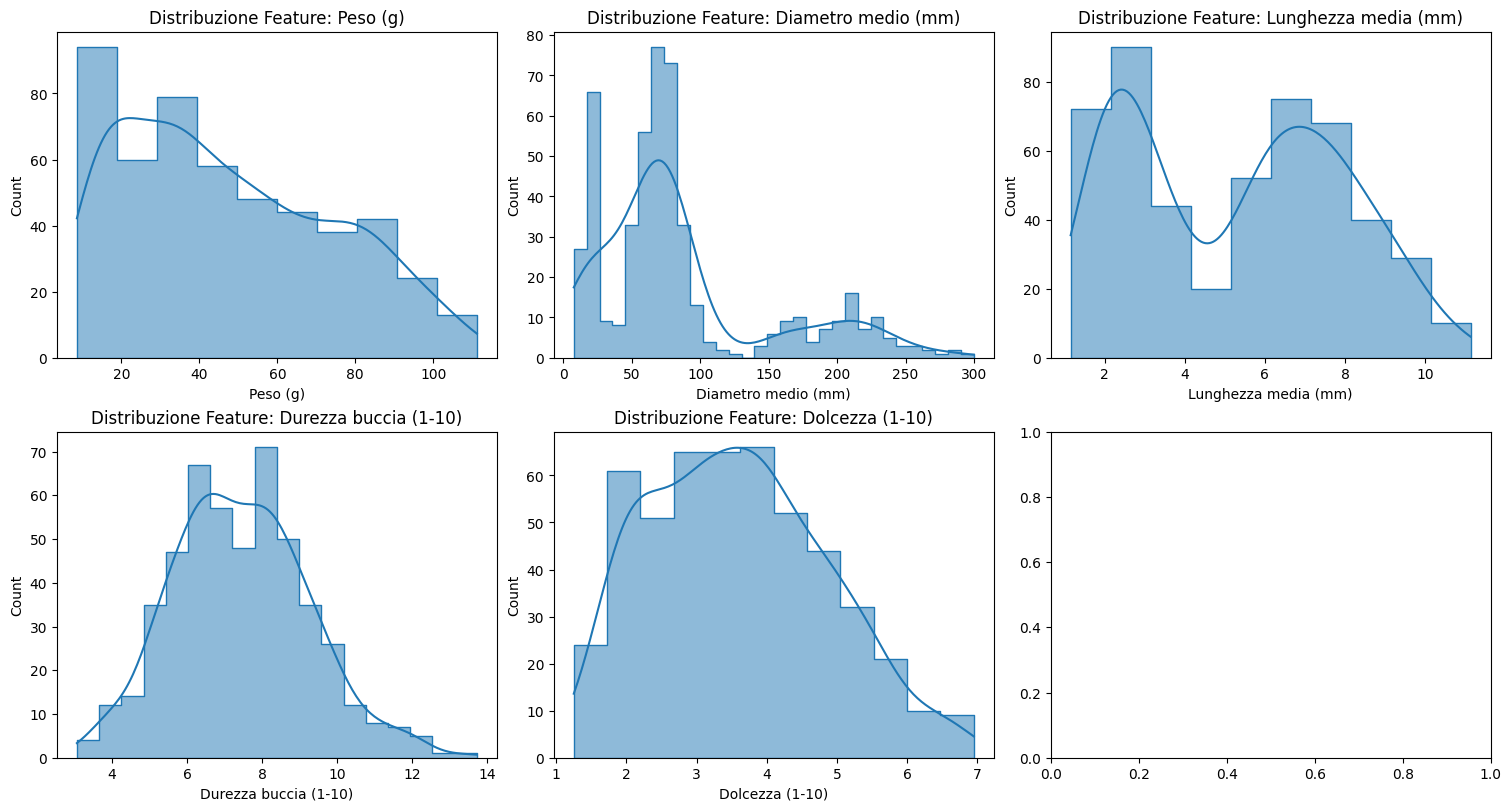

In [43]:
#Distribuzione delle feature

# Creazione una lista con i nomi delle sole colonne numeriche
feature_numeriche = ['Peso (g)', 'Diametro medio (mm)', 'Lunghezza media (mm)', 'Durezza buccia (1-10)', 'Dolcezza (1-10)']

# Creazione della griglia degli assi 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), layout='constrained')

axes = axes.flatten() #appiattimento della matrice di 2x3 su un unico vettore np per facilità di iterazione

for i, feature in enumerate(feature_numeriche):

  sns.histplot(data=df,
             x= feature,
             kde=True,
             element="step",
             ax = axes[i]

             )
  axes[i].set_title(f"Distribuzione Feature: {feature}")



Ritengo opportuno applicare una trasformazione logaritmica alle feature per cercare una distribuzione più normale di esse, siccome vedo un dataset sbilanciato sulle feature come peso, diametro (coda lunga), lunghezza media (due campane), dolcezza (left-skew).
Il modello KNN dovrebbe beneficiare da questa trasformazione perché rendendo lo spazio più isotropo il modello dovrebbe cogliere meglio le differenze sottili tra i frutti comuni

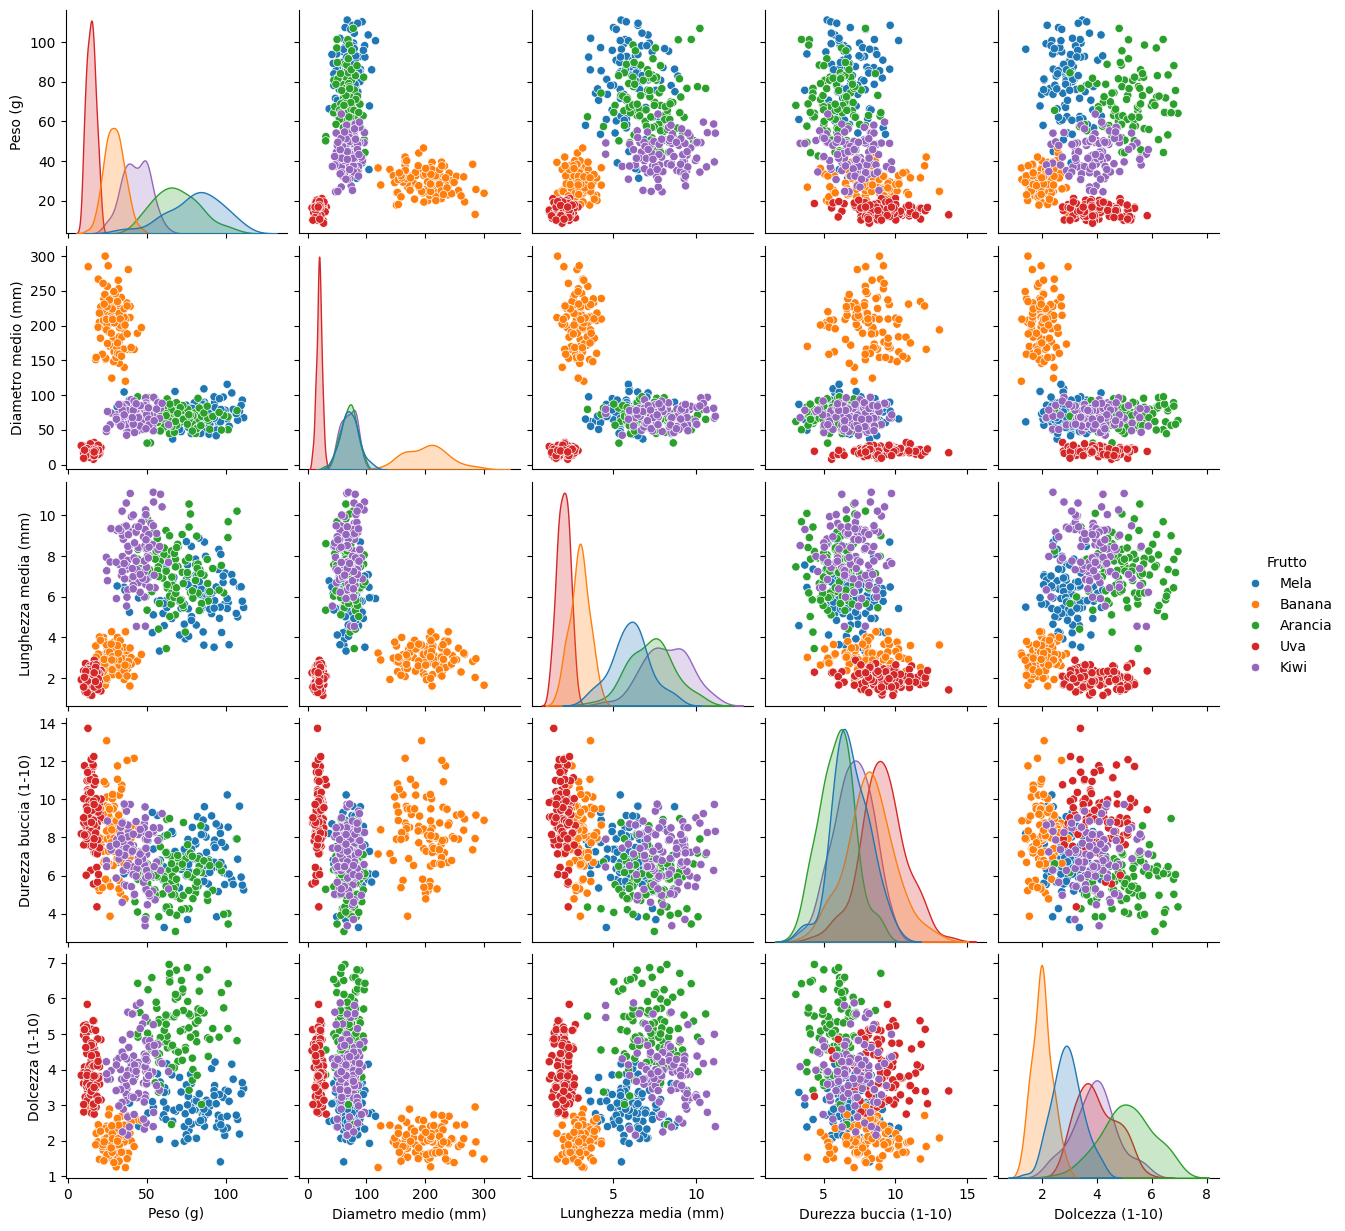

In [65]:
#valuto la distribuzione a coppia di feature per i frutti su un piano bidimensionale, voglio capire se ci sono pattern evidenti

sns.pairplot(df, hue= "Frutto")

Questo grafico mi può dare un'idea di quali feature separano bene le classi.
Da quel che vedo Peso-Dolcezza sembra separare meglio le classi.
L'uva è abbastanza identificabile tramite peso, diametro e lunghezza (giustamente è il frutto più piccolo tra quelli del dataframe)
Mela e Arancia si sovrappongono abbastanza in quasi tutti i grafici ma anche i kiwi si sovrappongono abbastanza

**FASE 3: split e standardizzazione dei dati**

In [44]:
#divisione del dataset in feature X e target y

X = df.drop(columns= "Frutto")
y = df["Frutto"]
x_ridotto = df[["Peso (g)","Dolcezza (1-10)"]]

random_seed = 0
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state = random_seed, shuffle = True)

In [45]:
#trasformazione delle feature e standardizzazione
from sklearn.preprocessing import PowerTransformer

# Inzizializzazione trasformatore
pt = PowerTransformer(method='yeo-johnson')

x_train = pt.fit_transform(x_train)
x_test = pt.transform(x_test)

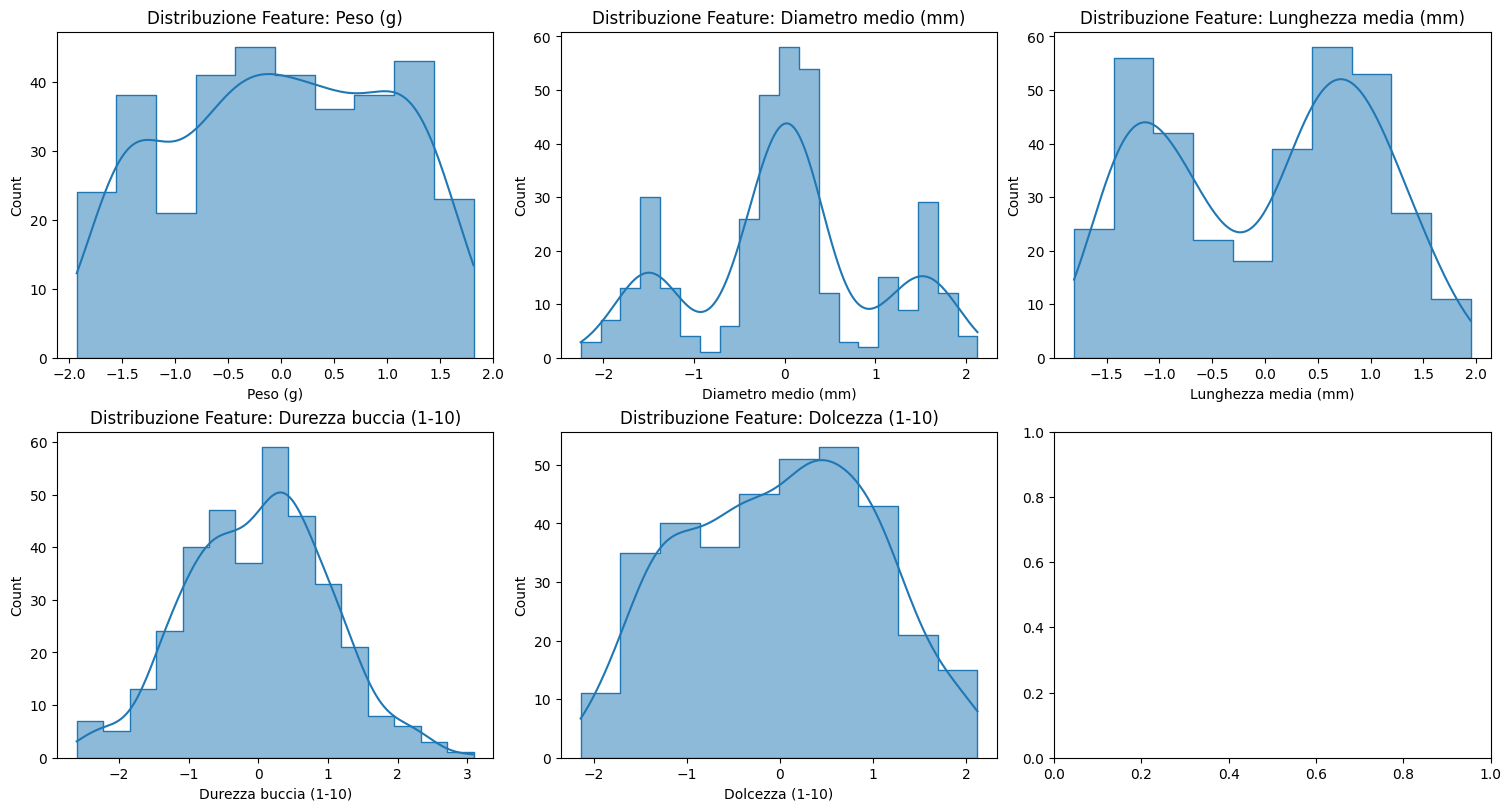

In [46]:
#verifica della distribuzione delle feature trasformate e standardizzate
df_transformed = pd.DataFrame(x_train, columns = feature_numeriche)

df_transformed.head()

# Creazione la griglia degli assi 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), layout='constrained')

axes = axes.flatten() #appiattimento della matrice di 2x3 su un unico vettore np per facilità di iterazione

for i, feature in enumerate(feature_numeriche):

  sns.histplot(data=df_transformed,
             x= feature,
             kde=True,
             element="step",
             ax = axes[i]

             )
  axes[i].set_title(f"Distribuzione Feature: {feature}")

Vedo una netta distinzione di campane sulla distribuzione delle feature Lunghezza Media e Diamentro medio. Qui mi fa presagire che ci sono delle categorie di frutti ben distint per diametro e lunghezza, dove immagino che il KNN potrebbe fare meno fatica ad eseguire la classificazione. Ora comunque le scale sono sistemate

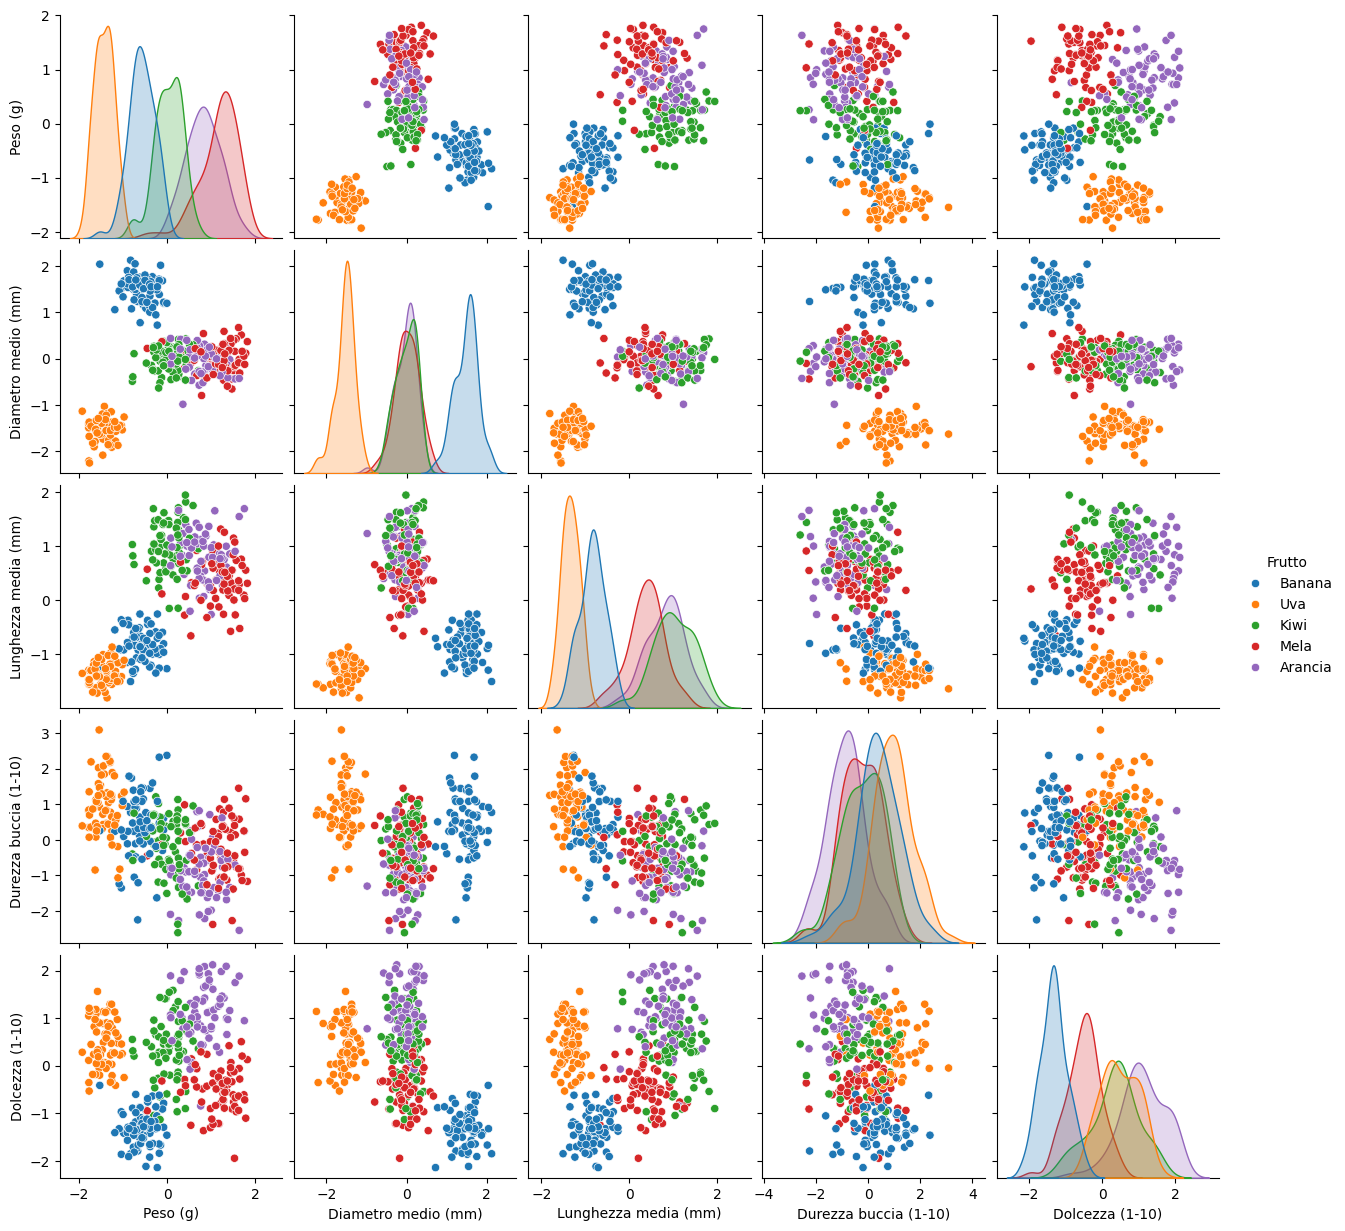

In [66]:
#creazione della stessa rappresentazione bidimensionale che è stata eseguita prima per vedere come si distribuiscono a coppie di feature i dati già trasformati di train e prendere delle decisioni in merito al modello

#aggiunta colonna frutto a df_transformed

df_transformed["Frutto"] = y_train.values


sns.pairplot(df_transformed, hue= "Frutto")

Sembra che in generale confermo il fatto che la distinzione tra banane e uva è più evidente quindi io mi aspetto che il modello che verrà addestrato non commetta molti errori nella distinzione di questi due frutti.
Per il resto ci potrebbero sicuramente essere degli errori, viste le sovrapposizioni generali che si trovano i tali grafici di distribuzione

**FASE 4: Addestramento del Modello KNN**

In [67]:
#definisco la funzione generale che valuta un modello di classificazione e in più restituisce i valori di accuracy che utilizzerò nei grafici a seguire

def evaluate_model(model, x_train, x_test, y_train, y_test, stampa_report = False):


  model.fit(x_train, y_train)
  y_pred_train = model.predict(x_train)
  y_pred_test = model.predict(x_test)

  if stampa_report:
    print("TRAIN\n")
    print(classification_report(y_train, y_pred_train))
    confusion_matrix(y_train, y_pred_train)

    print("TEST\n")
    print(classification_report(y_test, y_pred_test))

  return (accuracy_score(y_train, y_pred_train), accuracy_score(y_test, y_pred_test))



*MAIN*

In [50]:
train_accuracies = []
test_accuracies = []

for K in range(1, 21):

  knn = KNeighborsClassifier(n_neighbors=K)

  a1,a2 =evaluate_model(knn, x_train, x_test, y_train, y_test)

  train_accuracies.append(a1)
  test_accuracies.append(a2)

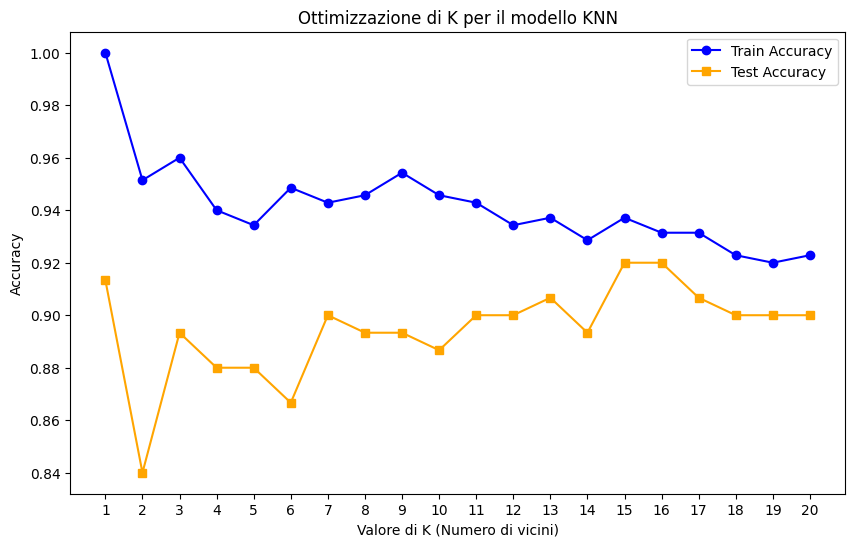

Train: [1.0, 0.9514285714285714, 0.96, 0.94, 0.9342857142857143, 0.9485714285714286, 0.9428571428571428, 0.9457142857142857, 0.9542857142857143, 0.9457142857142857, 0.9428571428571428, 0.9342857142857143, 0.9371428571428572, 0.9285714285714286, 0.9371428571428572, 0.9314285714285714, 0.9314285714285714, 0.9228571428571428, 0.92, 0.9228571428571428]
Test: [0.9133333333333333, 0.84, 0.8933333333333333, 0.88, 0.88, 0.8666666666666667, 0.9, 0.8933333333333333, 0.8933333333333333, 0.8866666666666667, 0.9, 0.9, 0.9066666666666666, 0.8933333333333333, 0.92, 0.92, 0.9066666666666666, 0.9, 0.9, 0.9]


In [63]:

k_values = range(1, 21)


plt.figure(figsize=(10, 6))

plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o', color='blue')

plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s', color='orange')

plt.title("Ottimizzazione di K per il modello KNN")
plt.xlabel("Valore di K (Numero di vicini)")
plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.legend()

plt.show()

print(f"Train: {train_accuracies}")
print(f"Test: {test_accuracies}")

Direi che il valore più accettabile di K è 15 per cui ho Accuracy 0.937 su train e 0.92 su test. L'errore di classificazione è semplicemente 1- Accuracy quindi ho un'errore di classificazione del 6.3% sul train e 8% sul test

**FASE 5: valutazione finale del Modello**

TRAIN

              precision    recall  f1-score   support

     Arancia       0.86      0.88      0.87        69
      Banana       1.00      1.00      1.00        73
        Kiwi       0.89      0.85      0.87        68
        Mela       0.93      0.94      0.94        71
         Uva       1.00      1.00      1.00        69

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

TEST

              precision    recall  f1-score   support

     Arancia       0.80      0.90      0.85        31
      Banana       1.00      1.00      1.00        27
        Kiwi       0.85      0.91      0.88        32
        Mela       1.00      0.79      0.88        29
         Uva       1.00      1.00      1.00        31

    accuracy                           0.92       150
   macro avg       0.93      0.92      0.92       150
weighted avg       0.93      0.92      0.92       150



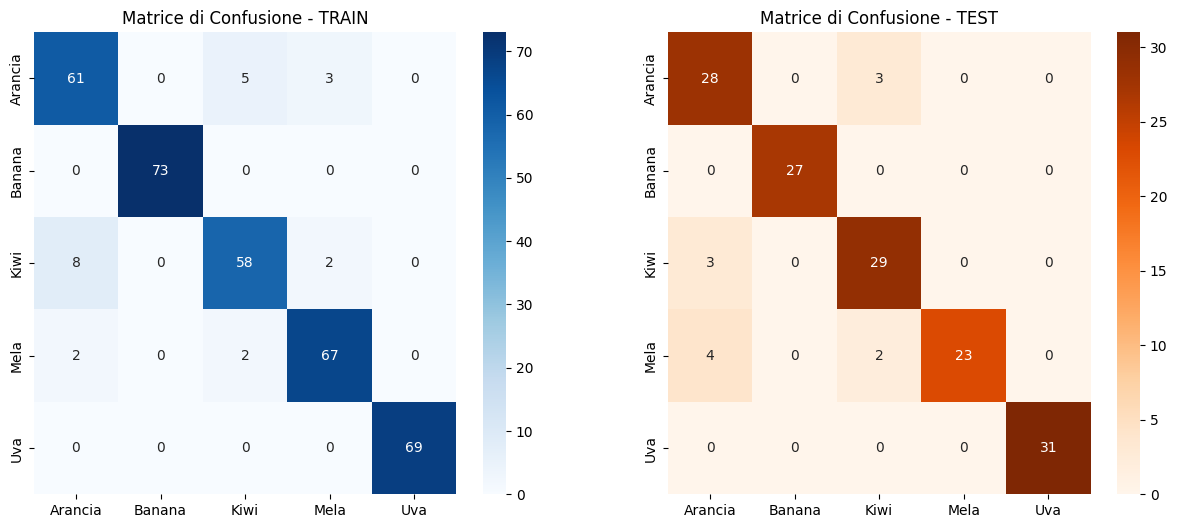

In [71]:
#riaddestramento del modello su K = 15 e verifica delle altre metriche del classification report

knn_finale = KNeighborsClassifier(n_neighbors=15)

knn_finale.fit(x_train, y_train)
y_pred_train = knn_finale.predict(x_train)
y_pred_test = knn_finale.predict(x_test)

#stampo tutte le metriche per il train set con la matrice di confusione
print("TRAIN\n")
print(classification_report(y_train, y_pred_train))
cm_train= confusion_matrix(y_train, y_pred_train)


#stampo tutte le metriche per il test set con la matrice di confusione
print("TEST\n")
print(classification_report(y_test, y_pred_test))
cm_test= confusion_matrix(y_test, y_pred_test)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.heatmap(cm_train, annot=True, cmap='Blues',
            xticklabels=knn_finale.classes_, yticklabels=knn_finale.classes_,
            ax=axes[0], fmt='g')
axes[0].set_title('Matrice di Confusione - TRAIN')

sns.heatmap(cm_test, annot=True, cmap='Oranges',
            xticklabels=knn_finale.classes_, yticklabels=knn_finale.classes_,
            ax=axes[1], fmt='g') #
axes[1].set_title('Matrice di Confusione - TEST')

plt.show()

Dalle matrice di confusione è evidente che il modello non sbaglia mai la classificazione banana e uva, come si poteva evincere dai grafici di dispersione eseguiti nella fase iniziale del progetto. Mentre fa più difficoltà a classificare bene arancia e mela e arancia e kiwi ma anche mela e kiwi.

In [77]:
#Cross Validation

cross_val= cross_val_score(knn_finale,x_train,y_train, cv = 5)

print("Scores per ogni fold:", cross_val)
print("Media:", cross_val.mean())
print("Deviazione standard:", cross_val.std())

Scores per ogni fold: [0.9        0.91428571 0.95714286 0.88571429 0.91428571]
Media: 0.9142857142857143
Deviazione standard: 0.023904572186687893


Dalla cross validation si evince che il modello finale è stabile. Media del 91.4% con una deviazione stanard del 2.4% circa quindi si può assumere che il modello generalizza bene.

**FASE 6: Validazione tramite GridSearchCV**

In [81]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1, 21))
}
knn_grid = KNeighborsClassifier()
grid_search = GridSearchCV(
                           estimator=knn_grid,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1

)


grid_search.fit(x_train,y_train)
y_pred_grid_train= grid_search.predict(x_train)
y_pred_grid_test= grid_search.predict(x_test)

print("I migliori parametri sono:", grid_search.best_params_)
print("Miglior score CV:", grid_search.best_score_)

I migliori parametri sono: {'n_neighbors': 6}
Miglior score CV: 0.9200000000000002


Si è trovata una sorpresa alla fine con Grid Search ovvero che il miglior parametro di primi vicini, quello che generalizza meglio ed è stabile, è 6.

TRAIN

              precision    recall  f1-score   support

     Arancia       0.85      0.93      0.89        69
      Banana       1.00      1.00      1.00        73
        Kiwi       0.94      0.87      0.90        68
        Mela       0.96      0.94      0.95        71
         Uva       1.00      1.00      1.00        69

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

TEST

              precision    recall  f1-score   support

     Arancia       0.65      0.90      0.76        31
      Banana       1.00      1.00      1.00        27
        Kiwi       0.86      0.78      0.82        32
        Mela       0.95      0.66      0.78        29
         Uva       1.00      1.00      1.00        31

    accuracy                           0.87       150
   macro avg       0.89      0.87      0.87       150
weighted avg       0.89      0.87      0.87       150



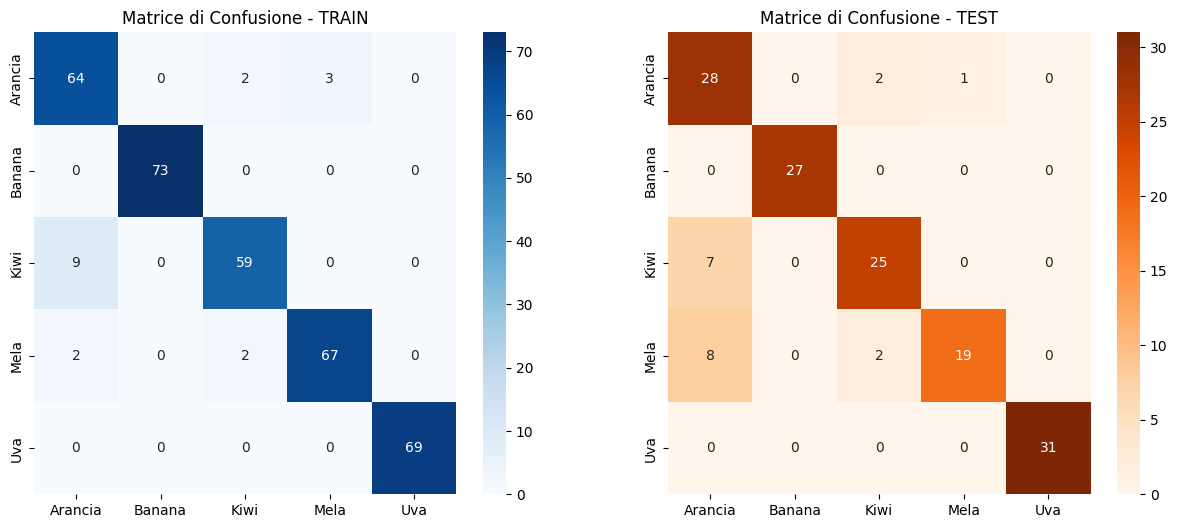

In [82]:
print("TRAIN\n")
print(classification_report(y_train, y_pred_grid_train))
cm_train= confusion_matrix(y_train, y_pred_grid_train)


#stampo tutte le metriche per il test set con la matrice di confusione
print("TEST\n")
print(classification_report(y_test, y_pred_grid_test))
cm_test= confusion_matrix(y_test, y_pred_grid_test)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.heatmap(cm_train, annot=True, cmap='Blues',
            xticklabels=knn_finale.classes_, yticklabels=knn_finale.classes_,
            ax=axes[0], fmt='g')
axes[0].set_title('Matrice di Confusione - TRAIN')

sns.heatmap(cm_test, annot=True, cmap='Oranges',
            xticklabels=knn_finale.classes_, yticklabels=knn_finale.classes_,
            ax=axes[1], fmt='g') #
axes[1].set_title('Matrice di Confusione - TEST')

plt.show()

Tuttavia per K = 6 si ottengono delle classificazioni peggiori rispetto a k= 15.
K = 15 era stato scelto da un'analisi sul test set che restituiva un valore di accuracy maggiore per k = 15 ma quel test set ha probabilmente una conformazione casuale (con random_state = 0) per cui K = 15 calza meglio di K =6.
Grid Search infatti non conosce il test set e quindi scegli k veramente solo sulla base del train set.

**FASE 7: Altri grafici sui risultati**

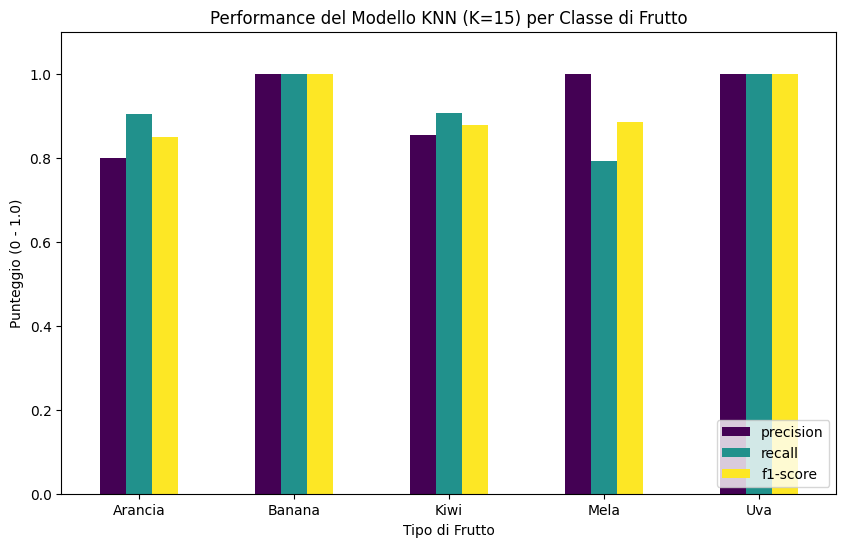

In [87]:
# Grafico esplicativo dei risultati ottenutti dal modello con k = 15
# creazione del dizionario con i risultati del classification report
report_dict = classification_report(y_test, y_pred_test, output_dict=True)
# creazione del DataFrame con frutti sull'asse x
df_report = pd.DataFrame(report_dict).transpose()

#esclusione delle righe  'accuracy', 'macro avg' e 'weighted avg'
df_metriche_frutti = df_report.iloc[:-3, :-1]


#Creazione grafico a barre
df_metriche_frutti.plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Performance del Modello KNN (K=15) per Classe di Frutto')
plt.ylabel('Punteggio (0 - 1.0)')
plt.xlabel('Tipo di Frutto')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right') # Spostiamo la legenda in basso a destra
plt.show()